# <a id='toc1_'></a>[**Classify Waste Products Using Transfer Learning**](#toc0_)


### <a id='toc1_3_2_'></a>[Importing Required Libraries](#toc0_)


In [1]:
import numpy as np
import os
import random, shutil
import glob


from matplotlib import pyplot as plt
from matplotlib import pyplot
from matplotlib.image import imread

from os import makedirs,listdir
from shutil import copyfile
from random import seed
from random import random

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
# from tensorflow.keras.layers import Conv2D, MaxPooling2D,GlobalAveragePooling2D, Input
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from sklearn import metrics

import warnings
warnings.filterwarnings('ignore')


E0000 00:00:1782472518.093970      59 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782472518.158399      59 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782472518.716661      59 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782472518.716701      59 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782472518.716704      59 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782472518.716706      59 computation_placer.cc:177] computation placer already registered. Please check linka

## <a id='toc1_4_'></a>[**Print the version of tensorflow**](#toc0_)



In [2]:
print(tf.__version__)

2.19.0


.

### <a id='toc1_6_2_'></a>[Importing Data](#toc0_)



In [3]:
import requests
import zipfile
from tqdm import tqdm

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/kd6057VPpABQ2FqCbgu9YQ/o-vs-r-split-reduced-1200.zip"
file_name = "o-vs-r-split-reduced-1200.zip"

print("Downloading file")
with requests.get(url, stream=True) as response: # Send request to url with water flow data named as respond
    response.raise_for_status()   # Check the  url
    with open(file_name, 'wb') as f:   # Open in binary mode because zip is not text so it is in binary form and now f is blank file
        for chunk in response.iter_content(chunk_size=8192):   # It will break our dwonload data (response) in chunks of 8KB 
            f.write(chunk)  # WRITE this data into f blank file


def extract_file_with_progress(file_name):
    print("Extracting file with progress")
    with zipfile.ZipFile(file_name, 'r') as zip_ref: # Now call zipFile function and read(r)  zip file_name  and name it zip_ref
        members = zip_ref.infolist()  # Now it make list of all folder and images
        with tqdm(total=len(members), unit='file') as progress_bar: #tqdm is progress bar and this will count in member(i.e 1200)  and give unit as 10/s 
            for member in members:  # It will pick one by one file in members(i.e 1200)
                zip_ref.extract(member)   # Now it will extract
                progress_bar.update(1)    # tqdm (progress bar ) will upade 
    print("Finished extracting file")


extract_file_with_progress(file_name)  # Function call

print("Finished extracting file")
os.remove(file_name)  # Old zip file  removed

Extracting file with progress


100%|██████████| 1207/1207 [00:00<00:00, 6614.98file/s]

Finished extracting file
Finished extracting file


### <a id='toc1_6_3_'></a>[Define configuration options](#toc0_)

It's time to define some model configuration options.

*   **batch size** is set to 32.
*   The **number of classes** is 2.
*   You will use 20% of the data for **validation** purposes.
*   You have two **labels** in your dataset: organic (O), recyclable (R).


In [4]:
img_rows, img_cols = 150, 150
batch_size = 32
n_epochs = 10
n_classes = 2
val_split = 0.2
verbosity = 1
path = 'o-vs-r-split/train/'
path_test = 'o-vs-r-split/test/'
input_shape = (img_rows, img_cols, 3)
labels = ['O', 'R']
seed = 42

### <a id='toc1_6_4_'></a>[Loading Images using ImageGeneratorClass](#toc0_)

Transfer learning works best when models are trained on smaller datasets. 

The folder structure looks as follows:

```python
o-vs-r-split/
└── train
    ├── O
    └── R
└── test
    ├── O
    └── R
```


#### <a id='toc1_6_4_1_'></a>[ImageDataGenerators](#toc0_)


Now you will create ImageDataGenerators used for training, validation and testing.

Image data generators create batches of tensor image data with real-time data augmentation. The generators loop over the data in batches and are useful in feeding data to the training process. 



In [5]:
# Create ImageDataGenerators for training and validation and testing
train_datagen = ImageDataGenerator(
    validation_split = val_split,
    rescale=1.0/255.0,
	width_shift_range=0.1, 
    height_shift_range=0.1, 
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    validation_split = val_split,
    rescale=1.0/255.0,
)

test_datagen = ImageDataGenerator(
    rescale=1.0/255.0
)

In [6]:
train_generator = train_datagen.flow_from_directory(
    directory = path,
    seed = seed,
    batch_size = batch_size, 
    class_mode='binary',
    shuffle = True,
    target_size=(img_rows, img_cols),
    subset = 'training'   # give role
)

Found 800 images belonging to 2 classes.


In [7]:
val_generator = val_datagen.flow_from_directory(
    directory = path,
    seed = seed,
    batch_size = batch_size, 
    class_mode='binary',
    shuffle = True,
    target_size=(img_rows, img_cols),
    subset = 'validation'   # give role
)

Found 200 images belonging to 2 classes.


## <a id='toc1_7_'></a>[**Create a `test_generator` using the `test_datagen` object**](#toc0_)


In [8]:
test_generator = test_datagen.flow_from_directory(
    directory = path_test,
    class_mode = 'binary',
    seed = seed,
    batch_size = batch_size,
    shuffle = False,
    target_size = (img_rows, img_cols)
)

Found 200 images belonging to 2 classes.


## <a id='toc1_8_'></a>[**Print the length of the `train_generator`**](#toc0_)




In [9]:
print(len(train_generator))

25


Let's look at a few augmented images:


Labels: [np.str_('O'), np.str_('O'), np.str_('O'), np.str_('O'), np.str_('O')]


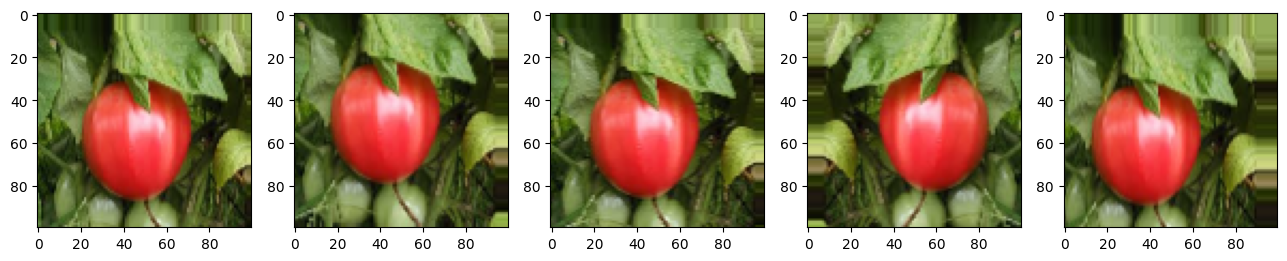

In [10]:
from pathlib import Path

IMG_DIM = (100, 100)

train_files = glob.glob('./o-vs-r-split/train/O/*')  # Move in folder
train_files = train_files[:20]  # Pick only first 20 images
train_imgs = [tf.keras.preprocessing.image.img_to_array(tf.keras.preprocessing.image.load_img(img, target_size=IMG_DIM)) for img in train_files] #  Load every
  # image(20)  with dimenstion (100,100) and convert into numbers(list)

train_imgs = np.array(train_imgs) # Convert that list to array
train_labels = [Path(fn).parent.name for fn in train_files] # Give us folder name in which all iamges are (like Organic)

img_id = 0  # Pick first image(index =0)
O_generator = train_datagen.flow(train_imgs[img_id:img_id+1], train_labels[img_id:img_id+1], batch_size=1)  # Pass data through train_datagen but with
                                           # 4D(0:0+1)<-img   ,              (0:0+1)<-label   -first(100,100,3)  Now(1,100,100,3)  

O = [next(O_generator) for i in range(0,5)] # get 5 augmented images (next mean next)
fig, ax = plt.subplots(1,5, figsize=(16, 6))
print('Labels:', [item[1][0] for item in O])# To get label of img  -->img with label(index 0-> Pixel/data)(index 1->Label)
                 #item[1]<- index 1(Label like Orange)  item[1][0]<-first word(O)
                 
l = [ax[i].imshow(O[i][0][0]) for i in range(0,5)]  #img dim--> (1,100,100,3)
 #Show img on screen as (O[0])<-- 1 , (O[0][0])<-- (100,100,3)<--Imge in batch


### <a id='toc1_8_1_'></a>[Pre-trained Models](#toc0_)

Pre-trained models are saved networks that have previously been trained on some large datasets. They are typically used for large-scale image-classification task. They can be used as they are or could be customized to a given task using transfer learning. These pre-trained models form the basis of transfer learning.

#### <a id='toc1_8_1_1_'></a>[VGG-16](#toc0_)

Let us load the VGG16 model.


In [11]:
from tensorflow.keras.applications import vgg16

input_shape = (150, 150, 3)
vgg = vgg16.VGG16(include_top=False,
                        weights='imagenet',
                        input_shape=input_shape)



I0000 00:00:1782472535.932285      59 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782472535.938316      59 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
output = vgg.layers[-1].output
output = tf.keras.layers.Flatten()(output)
basemodel = Model(vgg.input, output)

Next, you freeze the basemodel.


In [13]:
for layer in basemodel.layers: 
    layer.trainable = False

Create a new model on top. You add a Dropout layer for regularization, only these layers will change as for the lower layers you set `training=False` when calling the base model.


In [14]:
input_shape = basemodel.output_shape[1] # shape(None ,8192)--> shape[1]-->None<--batch_size(e.g 1,32 ,64)

model = Sequential()
model.add(basemodel)
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

## <a id='toc1_9_'></a>[**Print the summary of the model**](#toc0_)



In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ functional (Functional)         │ (None, 8192)           │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,172,673 (73.14 MB)

 Trainable params: 4,457,985 (17.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## <a id='toc1_10_'></a>[**Compile the model**](#toc0_)



In [16]:
for layer in basemodel.layers: 
    layer.trainable = False

model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-4),
    metrics=['accuracy']
)


You will use early stopping to avoid over-training the model.


In [17]:
from tensorflow.keras.callbacks import LearningRateScheduler  #Import learning rate schedular


checkpoint_path='O_R_tlearn_vgg16.keras'  #Save the model as this (it is checkpint)

# define step decay function
class LossHistory_(tf.keras.callbacks.Callback):  # Inherit Callback class(This function only made two empty list for  loss and lr on program starting)
    def on_train_begin(self, logs={}):    # Run this  fucntion when training begin
        self.losses = []   # An empty list use for loss and for learning rate(lr)
        self.lr = []
        
    def on_epoch_end(self, epoch, logs={}): # It run on the end of every epcoh.Keras tells which is epoch and logs={} store the detal like accuracy loss
        self.losses.append(logs.get('loss')) # Only loss is get from logs and add in losses(empty list that is in on_train_begin function)
        self.lr.append(exp_decay(epoch))  #Calculate speed of lr and add in lr(empty list that is in on_train_begin function)
        print('lr:', exp_decay(len(self.losses))) # Calculate the speed of learning rate in next epoch (It calculate next epoch lr with the prevous epoch end)

def exp_decay(epoch):  # Function to calculate speed of learning rate
    initial_lrate = 1e-4  #Initial speed
    k = 0.1  # Like brake 
    lrate = initial_lrate * np.exp(-k*epoch)  #  Formula--> Speed = 0.0001 * e^(-0.1 * epoch)
    return lrate
# learning schedule callback
loss_history_ = LossHistory_()
lrate_ = LearningRateScheduler(exp_decay)

keras_callbacks = [
      EarlyStopping(monitor = 'val_loss',   # Kis per nazar rakha ga
                    patience = 4,  # Kitna chakar k bad rok da ga training
                    mode = 'min',   # Kam loss ho
                    min_delta=0.01),  # Improvement kamz kam itni honi chiya warna record ni
      ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, mode='min')
]

callbacks_list_ = [loss_history_, lrate_] + keras_callbacks   # [(loss+lr),lrschedular + (earlystoping and modelcheckpoint)]

## <a id='toc1_11_'></a>[Fit and train the model](#toc0_)


In [18]:
extract_feat_model = model.fit(train_generator, 
                               steps_per_epoch=5, # Ek chakar (epoch) mein kitne dabbe (batches) dekhne hain
                               epochs=10,         # Total kitne chakar (epochs) lagane hain poori training mein
                               callbacks = callbacks_list_,   
                               validation_data=val_generator, 
                               validation_steps=val_generator.samples // batch_size,  # steps_per_epoch ka asli formula mtlb (100 images // 20 batch size = 5 steps per epoch)
                               verbose=1)


Epoch 1/10


I0000 00:00:1782472539.997395     156 service.cc:152] XLA service 0x7abcc000dce0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782472539.997446     156 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782472539.997453     156 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782472540.538871     156 cuda_dnn.cc:529] Loaded cuDNN version 91002


2/5 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.4141 - loss: 1.0550

I0000 00:00:1782472549.463874     156 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.4513 - loss: 0.9771lr: 9.048374180359596e-05
5/5 ━━━━━━━━━━━━━━━━━━━━ 14s 660ms/step - accuracy: 0.5063 - loss: 0.8645 - val_accuracy: 0.7188 - val_loss: 0.5959 - learning_rate: 1.0000e-04
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.6029 - loss: 0.6327lr: 8.187307530779819e-05
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 422ms/step - accuracy: 0.6500 - loss: 0.6037 - val_accuracy: 0.7188 - val_loss: 0.5720 - learning_rate: 9.0484e-05
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.6947 - loss: 0.5921lr: 7.408182206817179e-05
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 360ms/step - accuracy: 0.7000 - loss: 0.5733 - val_accuracy: 0.7917 - val_loss: 0.5024 - learning_rate: 8.1873e-05
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.7711 - loss: 0.4969 lr: 6.703200460356394e-05
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 364ms/step - accuracy: 0.7437 - loss: 0.5124 - val_accuracy: 0.7969 - val_loss: 0.4693 - learning_rate: 7.4082e-05
Epo

### <a id='toc1_11_1_'></a>[Plot loss curves for training and validation sets (extract_feat_model)](#toc0_)


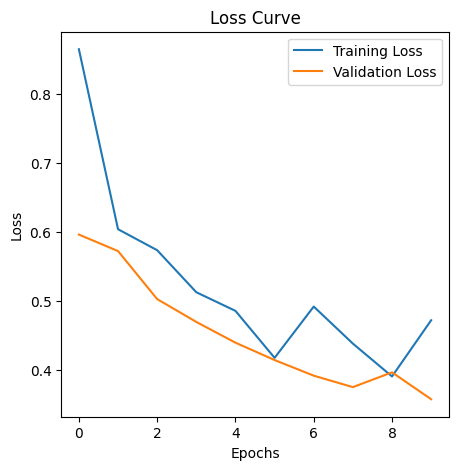

In [19]:
import matplotlib.pyplot as plt

history = extract_feat_model

# plot loss curve
plt.figure(figsize=(5, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

### <a id='toc1_11_2_'></a>[**Plot accuracy curves for training and validation sets (extract_feat_model)**](#toc0_)




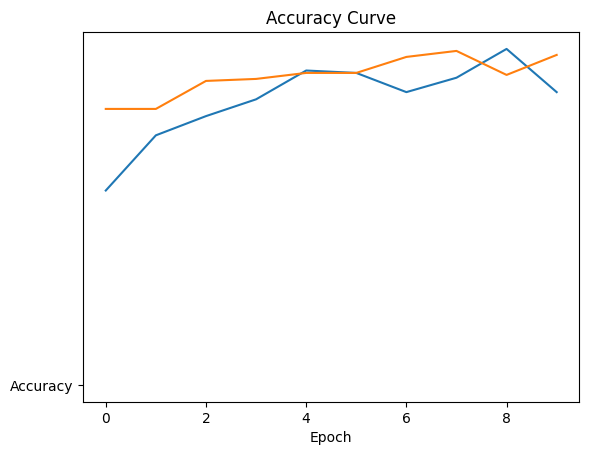

In [20]:
import matplotlib.pyplot as plt

history = extract_feat_model
figsize = (5,5)
plt.plot(history.history['accuracy'], label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel("Epoch")
plt.plot("Accuracy")

## <a id='toc1_12_'></a>[Fine-Tuning model](#toc0_)

Fine-tuning is an optional step in transfer learning, it usually ends up improving the performance of the model. 

You will **unfreeze** one layer from the base model and train the model again.


In [21]:
from tensorflow.keras.applications import vgg16

input_shape = (150, 150, 3)
vgg = vgg16.VGG16(include_top=False,
                        weights='imagenet',
                        input_shape=input_shape)

output = vgg.layers[-1].output
output = tf.keras.layers.Flatten()(output)
basemodel = Model(vgg.input, output)

for layer in basemodel.layers:      
    layer.trainable = False

display([layer.name for layer in basemodel.layers])  # Layers k nam dakhna k liya ha

set_trainable = False
 
for layer in basemodel.layers:           # Har layer k pas bari bari ja raha ha
    if layer.name in ['block5_conv3']:   # Jab is nam ki layer aya gi to usa unfreez kar dana
        set_trainable = True
    if set_trainable:                    # Agr wo a gi to ab us sa nicha wali ko bhi unfreez kar do
        layer.trainable = True
    else:
        layer.trainable = False          # Warna uper wali ha to wo lock raha freez raha
for layer in basemodel.layers:
    print(f"{layer.name}: {layer.trainable}")

['input_layer_2',
 'block1_conv1',
 'block1_conv2',
 'block1_pool',
 'block2_conv1',
 'block2_conv2',
 'block2_pool',
 'block3_conv1',
 'block3_conv2',
 'block3_conv3',
 'block3_pool',
 'block4_conv1',
 'block4_conv2',
 'block4_conv3',
 'block4_pool',
 'block5_conv1',
 'block5_conv2',
 'block5_conv3',
 'block5_pool',
 'flatten_1']

input_layer_2: False
block1_conv1: False
block1_conv2: False
block1_pool: False
block2_conv1: False
block2_conv2: False
block2_pool: False
block3_conv1: False
block3_conv2: False
block3_conv3: False
block3_pool: False
block4_conv1: False
block4_conv2: False
block4_conv3: False
block4_pool: False
block5_conv1: False
block5_conv2: False
block5_conv3: True
block5_pool: True
flatten_1: True


Similar to what you did before, you will create a new model on top, and add a Dropout layer for regularization.


In [22]:
model = Sequential()
model.add(basemodel)
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

checkpoint_path='O_R_tlearn_fine_tune_vgg16.keras'

# learning schedule callback
loss_history_ = LossHistory_()
lrate_ = LearningRateScheduler(exp_decay)

keras_callbacks = [
      EarlyStopping(monitor = 'val_loss', 
                    patience = 4, 
                    mode = 'min', 
                    min_delta=0.01),
      ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, mode='min')
]

callbacks_list_ = [loss_history_, lrate_] + keras_callbacks

model.compile(loss='binary_crossentropy',
              optimizer=optimizers.RMSprop(learning_rate=1e-4),
              metrics=['accuracy'])

fine_tune_model = model.fit(train_generator, 
                    steps_per_epoch=5, 
                    epochs=10,
                    callbacks = callbacks_list_,   
                    validation_data=val_generator, 
                    validation_steps=val_generator.samples // batch_size, 
                    verbose=1)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.4611 - loss: 0.8696lr: 9.048374180359596e-05
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 688ms/step - accuracy: 0.5375 - loss: 0.8474 - val_accuracy: 0.7240 - val_loss: 0.5543 - learning_rate: 1.0000e-04
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.6665 - loss: 0.6006lr: 8.187307530779819e-05
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 431ms/step - accuracy: 0.7125 - loss: 0.5575 - val_accuracy: 0.7969 - val_loss: 0.4438 - learning_rate: 9.0484e-05
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.7504 - loss: 0.5009lr: 7.408182206817179e-05
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 392ms/step - accuracy: 0.7625 - loss: 0.4977 - val_accuracy: 0.8438 - val_loss: 0.4014 - learning_rate: 8.1873e-05
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.8003 - loss: 0.4265lr: 6.703200460356394e-05
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 391ms/step - accuracy: 0.8062 - loss: 0.4350 - val_accuracy: 0.8438 - val_loss: 0.3781 - learning_rate: 7.4

### <a id='toc1_12_1_'></a>[**Plot loss curves for training and validation sets (fine tune model)**](#toc0_)



Text(0, 0.5, 'Loss')

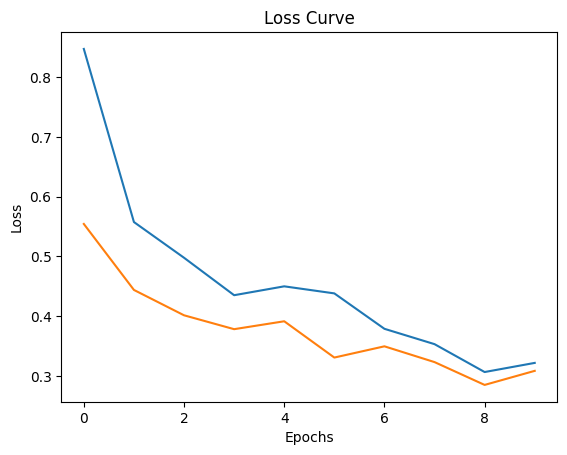

In [24]:
history = fine_tune_model

figsize = (5,5)
plt.plot(history.history['loss'], label = 'Training loss')
plt.plot(history.history['val_loss'],label = 'Validation Loss')
plt.title('Loss Curve')
plt.xlabel("Epochs")
plt.ylabel("Loss")

### <a id='toc1_12_2_'></a>[**Plot accuracy curves for training and validation sets  (fine tune model)**](#toc0_)



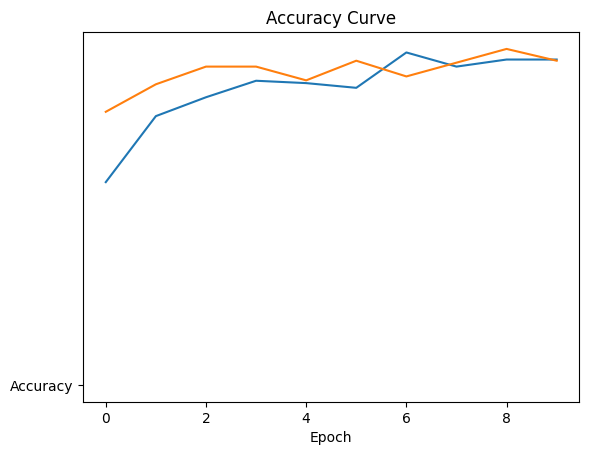

In [25]:
history = fine_tune_model

figsize = (5,5)
plt.plot(history.history['accuracy'], label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel("Epoch")
plt.plot("Accuracy")

## <a id='toc1_13_'></a>[Evaluate both models on test data](#toc0_)

- Load saved models
- Load test images
- Make predictions for both models
- Convert predictions to class labels
- Print classification report for both models


In [26]:
from pathlib import Path

# Load saved models
extract_feat_model = tf.keras.models.load_model('O_R_tlearn_vgg16.keras')
fine_tune_model = tf.keras.models.load_model('O_R_tlearn_fine_tune_vgg16.keras')

IMG_DIM = (150, 150)

# Load test images
test_files_O = glob.glob('./o-vs-r-split/test/O/*')
test_files_R = glob.glob('./o-vs-r-split/test/R/*')
test_files = test_files_O[:50] + test_files_R[:50]

test_imgs = [tf.keras.preprocessing.image.img_to_array(tf.keras.preprocessing.image.load_img(img, target_size=IMG_DIM)) for img in test_files]
test_imgs = np.array(test_imgs)
test_labels = [Path(fn).parent.name for fn in test_files]

# Standardize
test_imgs_scaled = test_imgs.astype('float32')
test_imgs_scaled /= 255

class2num_lt = lambda l: [0 if x == 'O' else 1 for x in l]
num2class_lt = lambda l: ['O' if x < 0.5 else 'R' for x in l]

test_labels_enc = class2num_lt(test_labels)

# Make predictions for both models
predictions_extract_feat_model = extract_feat_model.predict(test_imgs_scaled, verbose=0)
predictions_fine_tune_model = fine_tune_model.predict(test_imgs_scaled, verbose=0)

# Convert predictions to class labels
predictions_extract_feat_model = num2class_lt(predictions_extract_feat_model)
predictions_fine_tune_model = num2class_lt(predictions_fine_tune_model)

# Print classification report for both models
print('Extract Features Model')
print(metrics.classification_report(test_labels, predictions_extract_feat_model))
print('Fine-Tuned Model')
print(metrics.classification_report(test_labels, predictions_fine_tune_model))


Extract Features Model
              precision    recall  f1-score   support

           O       0.80      0.80      0.80        50
           R       0.80      0.80      0.80        50

    accuracy                           0.80       100
   macro avg       0.80      0.80      0.80       100
weighted avg       0.80      0.80      0.80       100

Fine-Tuned Model
              precision    recall  f1-score   support

           O       0.82      0.80      0.81        50
           R       0.80      0.82      0.81        50

    accuracy                           0.81       100
   macro avg       0.81      0.81      0.81       100
weighted avg       0.81      0.81      0.81       100



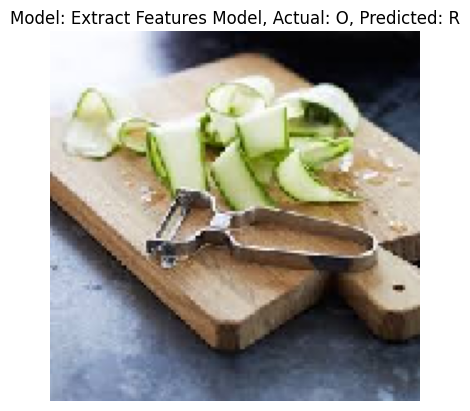

In [27]:
# Plot one of the images with actual label and predicted label as title
def plot_image_with_title(image, model_name, actual_label, predicted_label):
    plt.imshow(image)
    plt.title(f"Model: {model_name}, Actual: {actual_label}, Predicted: {predicted_label}")
    plt.axis('off')
    plt.show()

# Specify index of image to plot, for example index 0
index_to_plot = 0
plot_image_with_title(
    image=test_imgs[index_to_plot].astype('uint8'),
    model_name='Extract Features Model',
    actual_label=test_labels[index_to_plot], 
    predicted_label=predictions_extract_feat_model[index_to_plot],
    )

### <a id='toc1_13_1_'></a>[**Plot a test image using Extract Features Model (index_to_plot = 1)**](#toc0_)



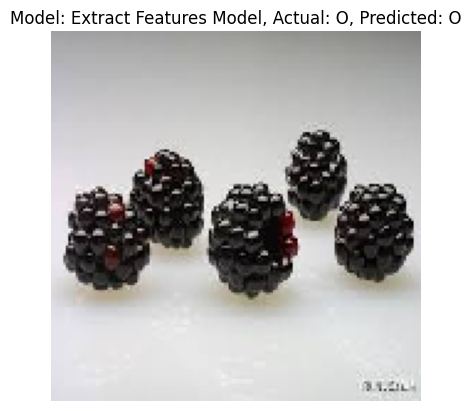

In [28]:
plot_image_with_title(
    image=test_imgs[1].astype('uint8'),
    model_name='Extract Features Model',
    actual_label=test_labels[1], 
    predicted_label=predictions_extract_feat_model[1],
)

### <a id='toc1_13_2_'></a>[**Plot a test image using Fine-Tuned Model (index_to_plot = 1)**](#toc0_)



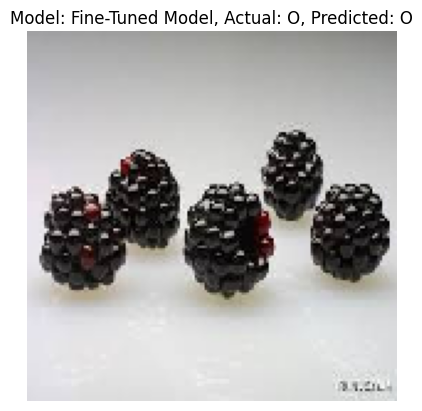

In [29]:
plot_image_with_title(
    image=test_imgs[1].astype('uint8'),
    model_name='Fine-Tuned Model',
    actual_label=test_labels[1], 
    predicted_label=predictions_fine_tune_model[1],
)